# Implementing GOTU: Generalization on the Unseen, Logic Reasoning and Degree Curriculum

Code for the ECE 570 Course Project Spring 2025.

## Prepare environment

In [1]:
import numpy as np
import itertools
import random
import torch
from torch import optim, nn
from torch.utils.data import TensorDataset, DataLoader
import time
import matplotlib.pyplot as plt
from einops import rearrange, repeat

The following block is not original, but adapted from [Dosovitskiy et al., 2020](https://arxiv.org/abs/2010.11929) as in the reimplemented paper.

This can be justified as it is not a novel contribution from the paper, and essentially a library that they used to get their results

In [2]:
# begin code adapted from lucidrains/vit-pytorch/vit.py (https://github.com/lucidrains/vit-pytorch)
class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fn = fn

    def forward(self, x, **kwargs):
        return self.fn(self.norm(x), **kwargs)


class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout = 0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)


class Attention(nn.Module):
    def __init__(self, dim, heads = 8, dim_head = 64, dropout = 0.):
        super().__init__()
        inner_dim = dim_head *  heads
        project_out = not (heads == 1 and dim_head == dim)

        self.heads = heads
        self.scale = dim_head ** -0.5

        self.attend = nn.Softmax(dim = -1)
        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias = False)

        self.to_out = nn.Sequential(
            nn.Linear(inner_dim, dim),
            nn.Dropout(dropout)
        ) if project_out else nn.Identity()

    def forward(self, x):
        qkv = self.to_qkv(x).chunk(3, dim = -1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h = self.heads), qkv)

        dots = torch.matmul(q, k.transpose(-1, -2)) * self.scale

        attn = self.attend(dots)

        out = torch.matmul(attn, v)
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)


class Transformer(nn.Module):
    def __init__(self, dim, depth, heads, dim_head, mlp_dim, dropout = 0.):
        super().__init__()
        self.layers = nn.ModuleList([])
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                PreNorm(dim, Attention(dim, heads = heads, dim_head = dim_head, dropout = dropout)),
                PreNorm(dim, FeedForward(dim, mlp_dim, dropout = dropout))
            ]))

    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x) + x
        return x



class TokenTransformer(nn.Module):
    def __init__(self, *, seq_len, output_dim, dim, depth, heads, mlp_dim, pool='cls',
            dim_head=64, dropout=0., emb_dropout=0., inputs_are_pos_neg_ones=True, albert=False):
        super().__init__()

        self._inputs_are_pos_neg_ones = inputs_are_pos_neg_ones
        self.token_embedding = nn.Embedding(num_embeddings=2, embedding_dim=dim)
        self.pos_embedding = nn.Parameter(torch.randn(1, seq_len + 1, dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.dropout = nn.Dropout(emb_dropout)
        self.albert = albert


        self.transformer = Transformer(dim, depth, heads, dim_head, mlp_dim, dropout)

        self.pool = pool
        self.to_latent = nn.Identity()

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, output_dim)
        )

    def forward(self, inputs):
        if self._inputs_are_pos_neg_ones:
            # convert from +1/-1 to 0/1
            inputs = (inputs + 1) / 2
        inputs = inputs.int()
        x = self.token_embedding(inputs)
        b, n, _ = x.shape

        cls_tokens = repeat(self.cls_token, '() n d -> b n d', b = b)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embedding[:, :(n + 1)]
        x = self.dropout(x)

        x = self.transformer(x)

        x = x.mean(dim = 1) if self.pool == 'mean' else x[:, 0]

        x = self.to_latent(x)
        return self.mlp_head(x)

# end code adapted from lucidrains/vit-pytorch/vit.py (https://github.com/lucidrains/vit-pytorch)

Functions $f_n$ and partition function to create seen domain ($\Omega \setminus U$) and unseen domain ($U$). These were explicitly seen in *Section 4: Experiments*

In [3]:
functions = {

    # f_1(x) =  x_0*x_1 - 1.25*x_1*x_2 + 1.5*x_2*x_0
    # U_1 = x_0 * x_1 * x_2 = -1
    'f1': {
        'target_function': lambda X: X[:, 0] * X[:, 1] - 1.25 * X[:, 1] * X[:, 2] + 1.5 * X[:, 2] * X[:, 0],
        'unseen_screener': lambda X: X[:, 0] * X[:, 1] * X[:,2] == -1,
        'mask': np.array([[0,0,0], [0,0,1], [0,1,0], [1,0,0], [1,1,0], [0,1,1], [1,0,1], [1,1,1]])
    },

    # f_2(x) = x_0 * x_1
    # U_2 = x_0, x_1 = (-1, -1)
    'f2': {
        'target_function': lambda X: X[:, 0] * X[:, 1],
        'unseen_screener': lambda X: (X[:, 0] == -1) & (X[:, 1] == -1),
        'mask': np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
     },

    # f_3(x) = x_0 * x_1 * x_2 + x_0 * x_3 * x_4 * x_5
    # U_3 = x_0, x_1, x_2 = (-1, -1, -1)
    'f3': {
        'target_function': lambda X: sum(X[:, i] * X[:, (i + 1) % 15] * X[:, (i + 2) % 15] for i in range(0, 15)),
        'unseen_screener': lambda X: (X[:, 0] == -1) & (X[:, 1] == -1) & (X[:, 2] == -1),
        'mask': np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     [0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                     [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0]])
    }
}

Object that contains the main attributes and methods of the reimplementation

In [4]:
class ModelManager:
    def __init__(self, model_name, function_name, batch_size, learning_rate, epochs, dimension, optimizer, degree_curriculum):
        self.model_name = model_name
        self.function_name = function_name
        self.target_function = functions[function_name]['target_function']
        self.unseen_screener = functions[function_name]['unseen_screener']
        self.mask = functions[function_name]['mask']
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.dimension = dimension
        self.optimizer = optimizer
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.test_batch_size = 8192
        self.momentum = 0.0

        torch.manual_seed(0)
        random.seed(0)
        np.random.seed(0)

        self.epoch = []
        self.fourier_coefficients = []
        self.training_loss = []
        self.validation_loss = []
        self.test_loss = []

        self.degree_curriculum = degree_curriculum
        self.model = TokenTransformer(seq_len=self.dimension, output_dim=1, dim=256, depth=12, heads=6, mlp_dim=256).to(self.device)

    def generate_datasets(self):
        def generate_all_binaries(d):
            return np.array([list(seq) for seq in itertools.product([-1, 1], repeat=d)], dtype=np.float32)

        all_possible_binaries = generate_all_binaries(self.dimension)
        all_possible_binaries = all_possible_binaries[np.random.permutation(all_possible_binaries.shape[0])]
        self.train_X = all_possible_binaries[~self.unseen_screener(all_possible_binaries)]
        self.train_y = self.target_function(self.train_X)

        self.valid_X = generate_all_binaries(self.dimension)
        self.valid_X = self.valid_X[~self.unseen_screener(self.valid_X)]
        self.valid_y = self.target_function(self.valid_X)

        self.test_X = generate_all_binaries(self.dimension)
        self.test_y = self.target_function(self.test_X)
        self.test_y = self.target_function(self.test_X)

    def model_evaluation(self, epoch, train_loss):

        def fourier_walsh_transform(monomials, X, y):
            # make sure monomials have the same number of columns as X
            if (monomials.shape[1] < X.shape[1]):
                padding = np.zeros((monomials.shape[0], X.shape[1] - monomials.shape[1]), dtype=int)
                monomials = np.hstack((monomials, padding))

            # fw transform
            return ((-2 * ((monomials @ ((1 - X.T) / 2)) % 2) + 1) @ y) / y.shape[0]

        self.model.eval()
        monomials = self.mask
        with torch.no_grad():
            if monomials is not None:
                self.y_pred = torch.vstack([self.model(xb) for xb, _ in self.test_dl])
                self.coefficients.append(fourier_walsh_transform(monomials, self.test_X.cpu().detach().numpy(), self.y_pred.cpu().detach().numpy()))
                norms = []
                for dim in range(self.dimension + 1):
                    mask = monomials.sum(axis=1) == dim
                    selected_coeffs = self.coefficients[-1][mask]
                    squared_sum = (selected_coeffs ** 2).sum()
                    norms.append(squared_sum)
            valid_loss = sum(self.loss_func(self.model(xb), yb) for xb, yb in self.valid_dl) # Validation data is defined un the seen domain.
            if monomials is not None:
                test_loss = self.loss_func(self.y_pred, self.test_y)
            else:
                test_loss = sum(self.loss_func(self.model(xb), yb) for xb, yb in self.test_dl)  # Here the loss is on the whole space omega (seen and unseen).
                test_loss /= len(self.test_dl)
            valid_loss /= len(self.valid_dl)
            if train_loss is None:
                train_loss = valid_loss
            train_loss = train_loss.cpu().detach().numpy()
            valid_loss = valid_loss.cpu().detach().numpy()
            test_loss = test_loss.cpu().detach().numpy()
            self.test_losses.append(test_loss)
            self.epoch_log.append(epoch)

            if (monomials is not None):
                print("Coefficients:", self.coefficients[-1])
            print(f"Current epoch: {epoch:4}, Test Loss: {test_loss:0.4}, Elapsed Time:", time.strftime("%H:%M:%S",time.gmtime(time.time() - start_time)))

    def train(self):
        def degree_curriculum_datagen(self):
          leap_init = 0
          leap_i = 4
          while leap_init == 0 or len(self.train_dl) == 0:
              leap_init += leap_i
              indices = self.train_X.sum(dim=1) >= self.dimension - 2 * leap_init
              self.train_ds = TensorDataset(self.train_X[indices], self.train_y[indices])
              self.train_dl = DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True)
              indices = self.valid_X.sum(dim=1) >= self.dimension - 2 * leap_init
              self.valid_ds = TensorDataset(self.valid_X[indices], self.valid_y[indices])
              self.valid_dl = DataLoader(self.valid_ds, batch_size=self.test_batch_size)
          return leap_init, leap_i

        self.epoch_log = []
        self.test_losses = []
        self.coefficients = []

        self.train_y = self.train_y.reshape(-1, 1)
        self.valid_y = self.valid_y.reshape(-1, 1)
        self.test_y = self.test_y.reshape(-1, 1)

        self.train_X = torch.tensor(self.train_X, device=self.device)
        self.train_y = torch.tensor(self.train_y, device=self.device)
        self.valid_X = torch.tensor(self.valid_X, device=self.device)
        self.valid_y = torch.tensor(self.valid_y, device=self.device)
        self.test_X = torch.tensor(self.test_X, device=self.device)
        self.test_y = torch.tensor(self.test_y, device=self.device)


        if self.degree_curriculum == False:
          self.train_ds = TensorDataset(self.train_X, self.train_y)
          self.train_dl = DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True)
          self.valid_ds = TensorDataset(self.valid_X, self.valid_y)
          self.valid_dl = DataLoader(self.valid_ds, batch_size=self.test_batch_size)

        else:
            leap_init, leap_i =degree_curriculum_datagen(self)

        self.test_ds = TensorDataset(self.test_X, self.test_y)
        self.test_dl = DataLoader(self.test_ds, batch_size=self.test_batch_size)
        self.opt = optim.Adam(self.model.parameters(), lr=self.learning_rate, weight_decay=0.001)
        self.loss_func = nn.MSELoss()

        self.model_evaluation(-1, None)
        self.iter_counter = 0
        for epoch in range(self.epochs):
            self.model.train()
            train_loss = torch.tensor(0.0, device=self.device)
            for xb, yb in self.train_dl:
                self.iter_counter += 1
                pred = self.model(xb)
                loss = self.loss_func(pred, yb)
                train_loss += loss
                loss.backward()
                self.opt.step()
                self.opt.zero_grad()
            train_loss /= len(self.train_dl)
            if (epoch >= 0 and epoch % 1 == 0) or epoch == self.epochs - 1:
                self.model_evaluation(epoch, train_loss)
            if (self.degree_curriculum) and (train_loss < 0.001):
                if not leap_init < self.dimension:
                    break
                else:
                    leap_init += leap_i
                    print(f"Epoch: {epoch} -- curriculum changed to {leap_init}")

                    indices = self.train_X.sum(dim=1) >= self.dimension - 2 * leap_init
                    train_ds = TensorDataset(self.train_X[indices], self.train_y[indices])
                    self.train_dl = DataLoader(train_ds, batch_size=self.batch_size, shuffle=True)
                    indices = self.valid_X.sum(dim=1) >= self.dimension - 2 * leap_init
                    valid_ds = TensorDataset(self.valid_X[indices], self.valid_y[indices])
                    valid_dl = DataLoader(valid_ds, batch_size=self.test_batch_size)
        print("Number of iterations:", self.iter_counter)
        return

    def graph(self, monomial_labels):
          self.coefficients = self.coefficients
          data_matrix = np.array([arr.flatten() for arr in self.coefficients])

          monomials_over_time = data_matrix.T
          epochs = np.arange(monomials_over_time.shape[1])

          # Ensure monomial_labels matches the number of monomials
          if len(monomial_labels) < monomials_over_time.shape[0]:
              monomial_labels += [f'Monomial {i}' for i in range(len(monomial_labels), monomials_over_time.shape[0])]
          elif len(monomial_labels) > monomials_over_time.shape[0]:
              monomial_labels = monomial_labels[:monomials_over_time.shape[0]]

          markers = ['o-', 'x-', 'v-', '^-', 's-', 'p-', 'h-', 'd-', '>-', '<-']
          markers = (markers * ((monomials_over_time.shape[0] // len(markers)) + 1))[:monomials_over_time.shape[0]]

          plt.figure(figsize=(6, 5))
          for i in range(monomials_over_time.shape[0]):
              plt.plot(epochs, monomials_over_time[i], markers[i], label=monomial_labels[i])

          plt.xlabel("Epoch")
          plt.ylabel("Coefficient of the monomial")
          plt.title(f"{self.function_name} - Transformer")
          plt.legend()
          plt.tight_layout()
          plt.show()


def plot_curriculum_vs_no_curriculum(loss_curriculum, loss_no_curriculum):

    loss_curriculum = np.array(loss_curriculum)
    loss_no_curriculum = np.array(loss_no_curriculum)
    train_samples = np.arange(1, 1 + len(loss_curriculum))

    fig, ax = plt.subplots()

    ax.plot(train_samples, loss_curriculum, 'b--^', label='Curriculum')
    ax.plot(train_samples, loss_no_curriculum, 'k-v', label='No Curriculum')

    ax.set_xscale('linear')
    ax.set_yscale('log')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Test loss')
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()

Training and testing for DO1 and DO2

In [5]:
print("Training")
start_time = time.time()

# ------------------------------------------------------
# DO1: Prove min-degree bias of Transformer architecture
# ------------------------------------------------------

# Figure 1
figure_1 = ModelManager(
    model_name='transformer',
    function_name='f1',
    batch_size=256,
    learning_rate=0.00002,
    epochs=20,
    dimension=15,
    optimizer='adam',
    degree_curriculum=False,
)

figure_1.generate_datasets()
figure_1.train()

# Figure 2
figure_2 = ModelManager(
    model_name='transformer',
    function_name='f2',
    batch_size=256,
    learning_rate=0.00001,
    epochs=20,
    dimension=15,
    optimizer='adam',
    degree_curriculum=False,
)
figure_2.generate_datasets()
figure_2.train()

# Figure 3
figure_3 = ModelManager(
    model_name='transformer',
    function_name='f3',
    batch_size=256,
    learning_rate=0.00002,
    epochs=60,
    dimension=15,
    optimizer='adam',
    degree_curriculum=False,
)
figure_3.generate_datasets()
figure_3.train()

# -------------------------------------------
# DO2: Reimplement Degree Curriculum Learning
# -------------------------------------------

# Figure 4
figure_4 = ModelManager(
    model_name='transformer',
    function_name='f1',
    batch_size=256,
    learning_rate=0.00002,
    epochs=20,
    dimension=15,
    optimizer='adam',
    degree_curriculum=True,
)

figure_4.generate_datasets()
figure_4.train()

# Figure 5
figure_5 = ModelManager(
    model_name='transformer',
    function_name='f2',
    batch_size=256,
    learning_rate=0.00001,
    epochs=20,
    dimension=15,
    optimizer='adam',
    degree_curriculum=True,
)
figure_5.generate_datasets()
figure_5.train()

# Figure 6
figure_6 = ModelManager(
    model_name='transformer',
    function_name='f3',
    batch_size=256,
    learning_rate=0.00002,
    epochs=60,
    dimension=15,
    optimizer='adam',
    degree_curriculum=True,
)
figure_6.generate_datasets()
figure_6.train()


Training
Coefficients: [[ 7.29410850e-01]
 [-1.07339048e-02]
 [-8.71997866e-03]
 [-5.38705439e-03]
 [-5.89253652e-04]
 [-6.40130102e-04]
 [-7.73228201e-04]
 [-4.80066046e-06]]
Current epoch:   -1, Test Loss: 5.348, Elapsed Time: 00:00:07
Coefficients: [[-0.33790732]
 [ 1.07366137]
 [ 1.77478537]
 [-1.17126015]
 [ 0.0479599 ]
 [-0.05813717]
 [ 0.03185894]
 [ 0.15121867]]
Current epoch:    0, Test Loss: 10.36, Elapsed Time: 00:00:10
Coefficients: [[-0.10618005]
 [ 0.91044809]
 [ 1.42846077]
 [-1.16244858]
 [ 0.08547462]
 [-0.08038927]
 [ 0.05904126]
 [ 0.09552365]]
Current epoch:    1, Test Loss: 8.524, Elapsed Time: 00:00:13
Coefficients: [[-0.1021444 ]
 [ 0.91067116]
 [ 1.43727092]
 [-1.17244112]
 [ 0.08855818]
 [-0.07813063]
 [ 0.06174364]
 [ 0.09748745]]
Current epoch:    2, Test Loss: 8.563, Elapsed Time: 00:00:16
Coefficients: [[-0.0958909 ]
 [ 0.91045522]
 [ 1.43561531]
 [-1.17248945]
 [ 0.08965425]
 [-0.07705374]
 [ 0.06280851]
 [ 0.09755122]]
Current epoch:    3, Test Loss: 8.55

Output figures for paper

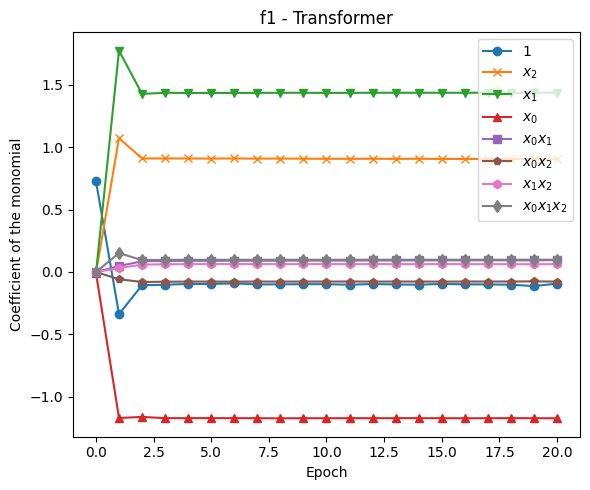

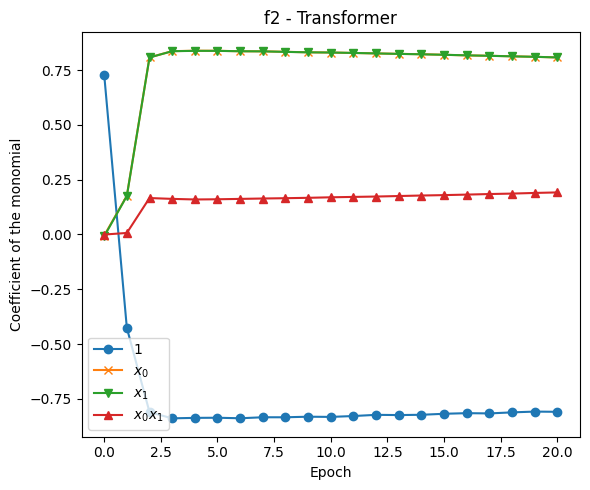

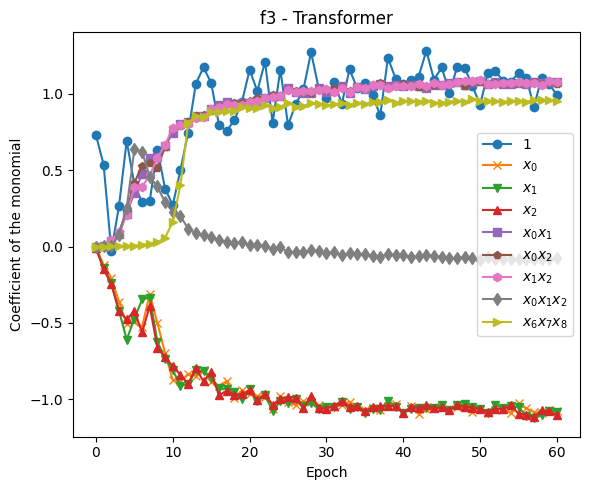

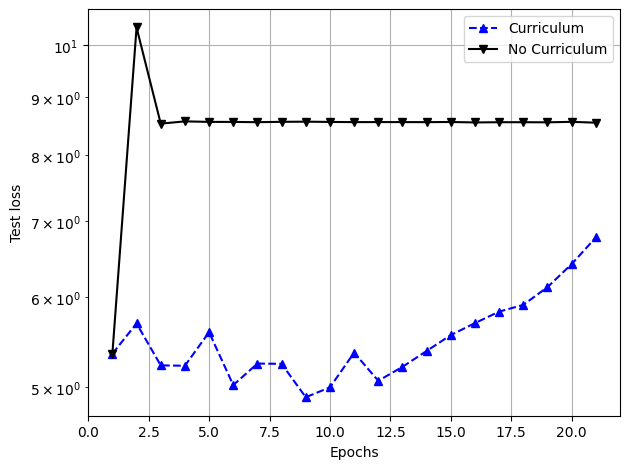

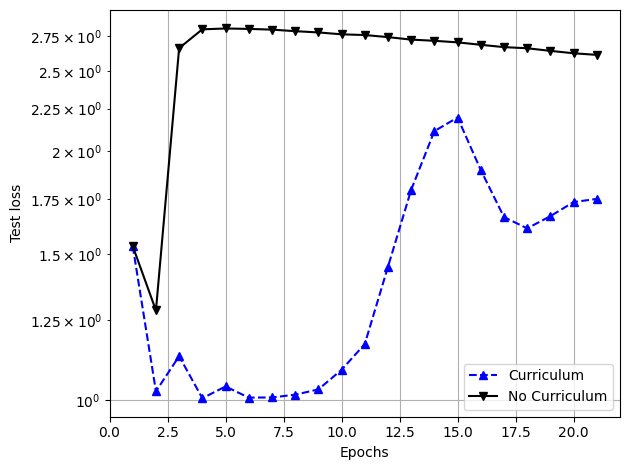

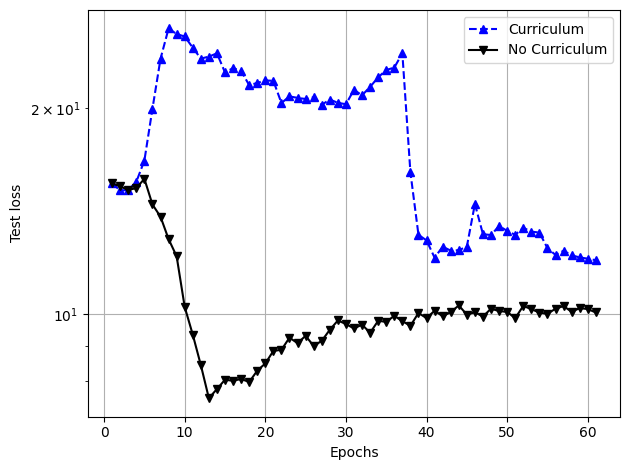

In [6]:
# ------------------------------------------------------
# DO1: Prove min-degree bias of Transformer architecture
# ------------------------------------------------------

monomial_labels_f1 = [
    "$1$",
    "$x_2$",
    "$x_1$",
    "$x_0$",
    "$x_0 x_1$",
    "$x_0 x_2$",
    "$x_1 x_2$",
    "$x_0 x_1 x_2$"
]

monomial_labels_f2 = [
    "$1$",
    "$x_0$",
    "$x_1$",
    "$x_0 x_1$"
]

monomial_labels_f3 = [
    "$1$",
    "$x_0$",
    "$x_1$",
    "$x_2$",
    "$x_0 x_1$",
    "$x_0 x_2$",
    "$x_1 x_2$",
    "$x_0 x_1 x_2$",
    "$x_6 x_7 x_8$"
]


figure_1.graph(monomial_labels_f1)
figure_2.graph(monomial_labels_f2)
figure_3.graph(monomial_labels_f3)

# -------------------------------------------
# DO2: Reimplement Degree Curriculum Learning
# -------------------------------------------

plot_curriculum_vs_no_curriculum(figure_4.test_losses, figure_1.test_losses)
plot_curriculum_vs_no_curriculum(figure_5.test_losses, figure_2.test_losses)
plot_curriculum_vs_no_curriculum(figure_6.test_losses, figure_3.test_losses)